In [1]:
from xaikd import models, attributors, datasets, bases
from xaikd.utils import metrics
from PIL import Image
import torch
from matplotlib import pyplot as plt
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset, DataLoader
import numpy as np

from tqdm import tqdm

In [2]:
model = models.get_model("cifar10-resnet18-p1")

In [3]:
dataset = datasets.construct("cifar10")

In [4]:
class SaltPepperCorruption(object):
    def __init__(self, severity_level: float):
        self.severity_level = severity_level

    def __call__(self, img: Image) -> Image:
        img = np.array(img)

        h, w, c = img.shape

        # we flip those pixels whose values below threshold
        binmask = np.random.rand(h, w, 1) > self.severity_level

        # we choose black (pepper)and white (salt).
        noisepixels = (np.random.rand(h, w, 1) > 0.5) * 255

        output = np.where(binmask, img, noisepixels)

        # we output PIL.Image to make the output compatible with test_transform,
        # which contains [ToTensor(), Normalization()]
        # This is similar to __getitem__(...) of
        # https://pytorch.org/vision/master/_modules/torchvision/datasets/cifar.html#CIFAR10
        return Image.fromarray(output.astype("uint8"))


In [5]:
train_dl =  dataset.loader(train_split=True)
val_dl =  dataset.loader(train_split=False)

In [6]:
dataset.transformation

Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
)

In [7]:
def get_dl_with_noise(severity, samples_per_class=500, train=True):
    ds = CIFAR10(
        root="./datasets/cifar10",
        train=train, 
        transform=transforms.Compose(
        [SaltPepperCorruption(severity), dataset.transformation]
        ), 
        download=True
    )
    
    np.random.seed(1)

    subset = Subset(
        ds,
        indices=datasets.selected_subset_samples_for_classes(
            np.array(ds.targets),
            np.arange(dataset.num_classes),
            samples_per_class=samples_per_class,
        )
    )

    
    dl = DataLoader(subset, num_workers=2, batch_size=64)
    return dl
get_dl_with_noise(0.1)

Files already downloaded and verified


Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


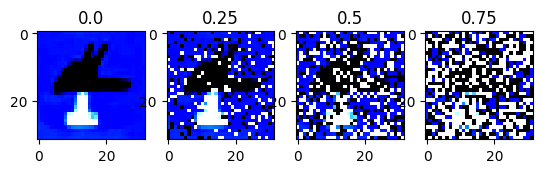

In [8]:
def viz():
    arr_severity = [0.0, 0.25, 0.5, 0.75]
    ncols = len(arr_severity)
    for six, severity in enumerate(arr_severity):
        
        plt.subplot(1, ncols, six+1) 
        plt.title(severity)
        dl = get_dl_with_noise(severity)
        x, _ = next(iter(dl))
        x = x[0].permute(1, 2, 0)

        plt.imshow(x)
viz()

In [14]:
def get_eigvecs(arr_act):
    
    _, eigvecs = np.linalg.eigh(arr_act.T @ arr_act / arr_act.shape[0])
    
    return np.copy(eigvecs[:, ::-1])


def compare_cosine_sim(layer):
    arr_severity = [0.1, 0.25, 0.5]
    
    arr_act_clean = attributors.extract_activation(
        model, layer, dataset,
        get_dl_with_noise(0.0)
    )
    U_clean = get_eigvecs(arr_act_clean)
    print(f"layer={layer}")
    for severity in arr_severity:
        arr_act_corrupted = attributors.extract_activation(
            model, layer, dataset,
            get_dl_with_noise(severity)
        )
        U_corrupted = get_eigvecs(arr_act_corrupted)
        cossim = U_clean[:, 0].dot(U_corrupted[:, 0])
        print(f"> severity={severity}: cossime={cossim:.4f}")

compare_cosine_sim("layer1")

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:49<00:00,  1.59it/s]


layer=layer1
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:48<00:00,  1.64it/s]


> severity=0.1: cossime=0.7412
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:48<00:00,  1.63it/s]


> severity=0.25: cossime=-0.6947
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.70it/s]

> severity=0.5: cossime=-0.6715


In [15]:
compare_cosine_sim("layer2")

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.70it/s]


layer=layer2
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:45<00:00,  1.72it/s]


> severity=0.1: cossime=-0.7428
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.71it/s]


> severity=0.25: cossime=-0.6620
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:47<00:00,  1.66it/s]

> severity=0.5: cossime=-0.5909


In [16]:
compare_cosine_sim("layer3")

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.70it/s]
/tmp/ipykernel_321536/2246869978.py:3: RuntimeWarning: invalid value encountered in matmul
  _, eigvecs = np.linalg.eigh(arr_act.T @ arr_act / arr_act.shape[0])


layer=layer3
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.71it/s]


> severity=0.1: cossime=0.6535
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:46<00:00,  1.71it/s]


> severity=0.25: cossime=0.5917
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:49<00:00,  1.59it/s]


> severity=0.5: cossime=0.5023


In [17]:
compare_cosine_sim("layer4")

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:48<00:00,  1.62it/s]
/tmp/ipykernel_321536/2246869978.py:3: RuntimeWarning: invalid value encountered in matmul
  _, eigvecs = np.linalg.eigh(arr_act.T @ arr_act / arr_act.shape[0])


layer=layer4
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:47<00:00,  1.65it/s]


> severity=0.1: cossime=0.6231
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:47<00:00,  1.67it/s]


> severity=0.25: cossime=0.6466
Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:48<00:00,  1.63it/s]


> severity=0.5: cossime=0.6144


# Robustify with Projection

In [62]:
SEVERITY = 0.0
LAYER = "layer1"

train_corrupted_dl = get_dl_with_noise(SEVERITY)

module = model.layer1[-1]

module

Files already downloaded and verified


BasicBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [63]:
from xaikd import utils
from xaikd.utils import interceptor

from torch.nn import functional as F

def attach_hook_intercept_layer_output(
    model, module
):

    return interceptor.attach_hook_intercept_module(module)

def logit_mod(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    logits = logits.clone()
    logits = logits * F.one_hot(targets, num_classes=10)
#     logits = logits * (1-F.one_hot(targets, num_classes=10))
#     print(logits*F.one_hot(targets, num_classes=10))
#     logits = logits*(logits > logits*F.one_hot(targets, num_classes=10))
    
    return logits

def extract_activation_context(
    model,
    module,
    dataset,
    data_loader: DataLoader,
    logit_modifier,
    device="cpu",
    number_of_selected_spatial_locations=20,
):
    arr_act = []
    arr_ctx = []

    try:
        
        module, hook = attach_hook_intercept_layer_output(model, module)

        with attributors.make_attributor_for(model, dataset.input_statistics) as attributor:
            for batch in tqdm(data_loader):
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad

                output_dimensions = act.shape[1:]

                # todo: check this with Gregoire again!
                ctx = torch.where(act.abs() > 0, rel / act, 0)

                assert torch.allclose(act * ctx, rel)

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act, ctx, num_locations=number_of_selected_spatial_locations
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


# def logit_mod(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
#     logits = logits.clone()
#     logits[:, targets] = 0
#     return logits


    
arr_act, arr_ctx  = extract_activation_context(
    model,
    module,
    dataset,
    train_corrupted_dl,
    logit_mod,
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [08:18<00:00,  6.31s/it]

output-dims=torch.Size([64, 32, 32])


In [71]:
act_mean = np.mean(arr_act, axis=0)

basis_pca = bases.get_basis("pca--uncentered")
Upca, _ = basis_pca.fit(arr_act, None, mean=act_mean)

In [65]:
# basis_prca = bases.get_basis("prca-recon--centered")
# Uprca, _ = basis_prca.fit(arr_act, arr_ctx, mean=act_mean)

[mode=recon,beta=0.0,device=cpu]:  11%|███████████████                                                                                                                           | 7/64 [00:05<00:47,  1.20it/s]


KeyboardInterrupt: 

In [72]:
def get_basis_at_k(name, k):
    
    if name == "identity":
        return np.eye(Upca.shape[0]), np.zeros_like(act_mean)
    
    elif name == "pca":
        return Upca[:, :k], np.zeros_like(act_mean)
    elif name == "prca-recon":
        raise
        return Uprca[:, :k], act_mean

In [67]:
# def ano(k):
#     U, _ = get_basis_at_k("pca", k=k)
    
#     np.random.seed(1)
    
#     W = np.random.randn(32, 64)
    
#     A = U @ U.T
#     print(f"k={k}")
#     print("norm2(U)", np.linalg.norm(U, ord=2))
#     print("norm2(UUT)", np.linalg.norm(A, ord=2))
    
#     print("norm(W)", np.linalg.norm(W, ord=2))
#     print("norm(W@UUT)", np.linalg.norm(W @ A, ord=2))
    
#     print(U.shape)
    
# ano(k=1)

In [73]:
from torchmetrics import Accuracy
from torch.nn import functional as F
import pandas as pd 

def get_accuracy(model: torch.nn.Module, dl: DataLoader, num_classes: int, device: str) -> float:
    metric = Accuracy(task="multiclass", num_classes=num_classes)

    for x, y in tqdm(dl):
        logits = model(x.to(device)).cpu()
        metric.update(logits, y)

    return float(metric.compute())

def construct_fh_hook_projection(A, mean): 

    A = torch.from_numpy(A).float().unsqueeze(2).unsqueeze(3)
    mean = torch.from_numpy(mean).reshape((1, -1, 1, 1))
    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        return F.conv2d(output - mean, A)  + mean

    return fh

@torch.no_grad()
def compute_accuracy_with_ks(arr_ks=[1, 8, 16, 32]):
    val_dl = get_dl_with_noise(severity=0.0, train=False, samples_per_class=500)

    rows = []
    for basis_name in ["identity", "pca", "prca-recon"][:2]:

        for k in arr_ks:
            if basis_name == "identity" and k > 1:
                break
            U, mean = get_basis_at_k(basis_name, k)

            
            A = U @ U.T

            try:
                hook = module.register_forward_hook(construct_fh_hook_projection(A, mean))
                clean_acc = get_accuracy(model, val_dl, num_classes=10, device="cpu")

                rows.append(
                    dict(basis_name=basis_name, k=k, acc=clean_acc)
                )

            finally:
                hook.remove()

    return pd.DataFrame(rows)


compute_accuracy_with_ks()

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:35<00:00,  2.25it/s]


,basis_name,k,acc
0,identity,1,0.9156
1,pca,1,0.1000
2,pca,8,0.8196
3,pca,16,0.9020
4,pca,32,0.9142


In [74]:
@torch.no_grad()
def compute_accuracy_with_severity(k=16, arr_severity=[0.1, 0.2, 0.3]):

    rows = []
    for basis_name in ["identity", "pca", "prca-recon"][:2]:

        for severity in arr_severity:
            
            val_dl = get_dl_with_noise(severity=severity, train=False, samples_per_class=500)


            U, mean = get_basis_at_k(basis_name, k)

            
            A = U @ U.T

            try:
                hook = module.register_forward_hook(construct_fh_hook_projection(A, mean))
                corrupted_acc = get_accuracy(model, val_dl, num_classes=10, device="cpu")

                rows.append(
                    dict(basis_name=basis_name, k=k, severity=severity, acc=corrupted_acc)
                )

            finally:
                hook.remove()

    return pd.DataFrame(rows)

compute_accuracy_with_severity(k=16)

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:35<00:00,  2.20it/s]


Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:36<00:00,  2.14it/s]


Files already downloaded and verified


...

Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:35<00:00,  2.26it/s]


Files already downloaded and verified


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:34<00:00,  2.28it/s]


,basis_name,k,severity,acc
0,identity,16,0.1,0.1404
1,identity,16,0.2,0.1406
2,identity,16,0.3,0.1314
3,pca,16,0.1,0.2328
4,pca,16,0.2,0.1146
5,pca,16,0.3,0.1028


Aims:
- can we use PRCA to defense agains noise in the input? 
    - project activations to the first $k$ sufficient components
    - expected: clean accuracy stays the SAME and corrupted accuracy improved (severity > 0)
    
    
with centering:
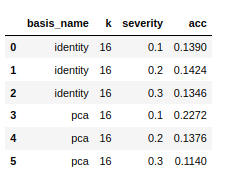

w/o centering